# Terkarantina: classifier ASD dari foto wajah

Notebook ini bukan sumber model apa pun untuk Neurogaze. Ia dijalankan sebagai audit
metodologis, untuk menunjukkan bagaimana dataset tanpa provenance dapat menghasilkan angka
yang terlihat bagus tetapi tidak dapat dipertanggungjawabkan.

Kelas positif adalah `Autistic` = label 1, dijaga assertion. Split memakai group
near-duplicate dan karena itu tidak dapat disebut person-safe. Threshold dipilih pada
validation lalu dikunci sebelum test disentuh. Audit shortcut dilakukan dengan classifier
properti berkas tanpa piksel sama sekali. Ketidakpastian diukur lewat bootstrap 2.000
resample. Ekspor artefak diblokir selama karantina aktif.

Status dataset: `reject_for_asd_modeling_and_quarantine`. Provenance, lisensi, consent,
demografi, definisi label operasional, dan ID partisipan semuanya tidak tersedia.

## 0. Governance gate, fail closed

Enam metadata wajib tidak tersedia untuk dataset ini. Notebook berhenti kecuali override
dinyatakan secara sadar untuk keperluan audit.

In [1]:
GOVERNANCE = {
    'provenance_sumber_gambar' : False,
    'lisensi_eksplisit'        : False,
    'consent_subjek'           : False,
    'metadata_demografi'       : False,
    'definisi_label_klinis'    : False,
    'participant_id'           : False,
}

# Set True hanya untuk menjalankan audit metodologis. Ini BUKAN izin untuk mengklaim hasil.
OVERRIDE_QUARANTINE = True
# Ekspor artefak model. Harus tetap False selama dataset terkarantina.
ALLOW_MODEL_EXPORT  = False

missing = [k for k, v in GOVERNANCE.items() if not v]
print('Metadata governance yang belum tersedia:')
for k in missing:
    print(f'  - {k}')

if missing and not OVERRIDE_QUARANTINE:
    raise RuntimeError(
        'QUARANTINE_FACE_DATASET: dataset tidak memenuhi syarat pemodelan ASD. '
        'Set OVERRIDE_QUARANTINE = True hanya untuk audit metodologis.')

print(f'\nMode: {"AUDIT (override aktif)" if missing else "NORMAL"}')
print('Seluruh angka di notebook ini TIDAK BOLEH dikutip sebagai performa klinis.')

Metadata governance yang belum tersedia:
  - provenance_sumber_gambar
  - lisensi_eksplisit
  - consent_subjek
  - metadata_demografi
  - definisi_label_klinis
  - participant_id

Mode: AUDIT (override aktif)
Seluruh angka di notebook ini TIDAK BOLEH dikutip sebagai performa klinis.


## 1. Setup dan import

In [2]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, auc,
                             ConfusionMatrixDisplay, accuracy_score, f1_score,
                             matthews_corrcoef, average_precision_score,
                             balanced_accuracy_score, roc_auc_score,
                             precision_recall_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

warnings.filterwarnings('ignore')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Konfigurasi

`CLASSES` menentukan label lewat urutan indeks, dan urutan itu menentukan siapa kelas positif.
Jika `Autistic` diletakkan di indeks 0, maka setiap metrik berbasis kelas positif (ROC,
sensitivity, average precision) akan menggambarkan Non-ASD, bukan ASD. Urutan di bawah
membuat label 1 = Autistic dan dijaga assertion.

In [3]:
# Path, robust terhadap perbedaan mount Kaggle
CANDIDATES = [
    Path('/kaggle/input/datasets/sha0401/autismdataset/AutismDataset/consolidated'),
    Path('/kaggle/input/autismdataset/AutismDataset/consolidated'),
    Path('/kaggle/input/autismdataset/consolidated'),
]
BASE_DIR = next((p for p in CANDIDATES if p.exists()), None)
if BASE_DIR is None:
    hits = [p for p in Path('/kaggle/input').rglob('consolidated') if p.is_dir()]
    if not hits:
        raise FileNotFoundError('Folder consolidated tidak ditemukan. Periksa Add Input.')
    BASE_DIR = hits[0]
print('BASE_DIR:', BASE_DIR)

# Urutan kelas menentukan label. Label 1 harus Autistic.
CLASSES = ['Non_Autistic', 'Autistic']
POS_LABEL, POS_NAME = 1, 'Autistic'
assert CLASSES[POS_LABEL] == POS_NAME, 'Kelas positif harus Autistic agar ROC tidak terbalik.'
print(f'Label 0 = {CLASSES[0]} | Label 1 = {CLASSES[1]}  <-- kelas positif = {POS_NAME}')

for c in CLASSES:
    print(f'  {c}: {len(list((BASE_DIR / c).glob("*")))} gambar')

# Hyperparameter
IMG_SIZE   = (300, 300)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

EPOCHS_P1, LR_P1, WARMUP_P1 = 25, 3e-4, 3
EPOCHS_P2, LR_P2, WARMUP_P2 = 30, 5e-5, 2
UNFREEZE_N = 50

VAL_RATIO, TEST_RATIO = 0.15, 0.15
N_BOOTSTRAP = 2000

# Split berdasarkan group near-duplicate. False = split acak per berkas.
GROUP_BY_NEAR_DUPLICATE = True

print(f'\nKonfigurasi OK — IMG={IMG_SIZE}, BATCH={BATCH_SIZE}')

BASE_DIR: /kaggle/input/datasets/sha0401/autismdataset/AutismDataset/consolidated
Label 0 = Non_Autistic | Label 1 = Autistic  <-- kelas positif = Autistic
  Non_Autistic: 1470 gambar
  Autistic: 1470 gambar

Konfigurasi OK — IMG=(300, 300), BATCH=32


## 3. Eksplorasi data

In [4]:
EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
records = []
for lbl, cls in enumerate(CLASSES):
    for f in sorted((BASE_DIR / cls).glob('*')):
        if f.suffix.lower() in EXTS:
            records.append({'filepath': str(f), 'class_name': cls, 'label': lbl})

df = pd.DataFrame(records)
class_counts = df['class_name'].value_counts().to_dict()

print('=== Distribusi kelas ===')
print(df.groupby(['label','class_name']).size().to_string())
print(f'\nTotal: {len(df)} gambar')
print(f'Imbalance ratio: {max(class_counts.values())/min(class_counts.values()):.2f}x')

# Verifikasi ulang pemetaan label -> nama kelas.
assert df.loc[df.label == 1, 'class_name'].unique().tolist() == ['Autistic']
print('\nVerifikasi lolos: label 1 benar-benar Autistic.')

=== Distribusi kelas ===
label  class_name  
0      Non_Autistic    1470
1      Autistic        1470

Total: 2940 gambar
Imbalance ratio: 1.00x

Verifikasi lolos: label 1 benar-benar Autistic.


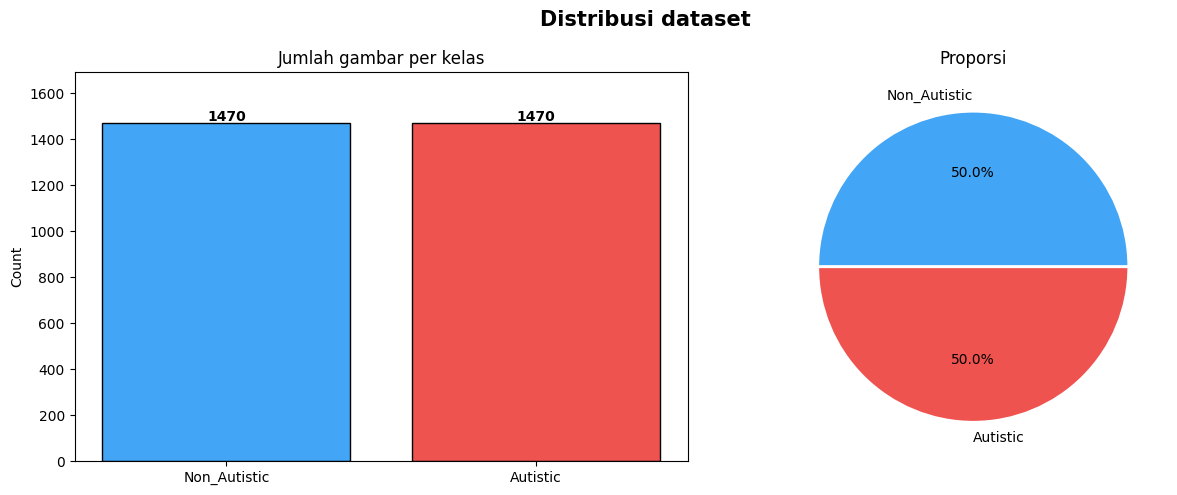

In [5]:
colors = ['#42A5F5', '#EF5350']   # urut sesuai CLASSES: Non_Autistic, Autistic
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi dataset', fontsize=15, fontweight='bold')
keys = CLASSES
vals = [class_counts[k] for k in keys]
axes[0].bar(keys, vals, color=colors, edgecolor='black')
axes[0].set_title('Jumlah gambar per kelas'); axes[0].set_ylabel('Count')
for i, v in enumerate(vals):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, max(vals) * 1.15)
axes[1].pie(vals, labels=keys, autopct='%1.1f%%', colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi')
plt.tight_layout(); plt.savefig('eda_distribution.png', dpi=150); plt.show()

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sampel gambar per kelas', fontsize=15, fontweight='bold')
for row, (cls, col) in enumerate(zip(CLASSES, colors)):
    files = df[df['class_name'] == cls]['filepath'].sample(5, random_state=SEED).tolist()
    for c, fpath in enumerate(files):
        axes[row, c].imshow(mpimg.imread(fpath))
        axes[row, c].set_title(f'{cls} (label {row})', color=col, fontsize=9)
        axes[row, c].axis('off')
plt.tight_layout(); plt.savefig('eda_samples.png', dpi=150); plt.show()

[keluaran gambar dihapus sebelum publikasi: sel ini merender wajah anak beserta labelnya. Angka dan grafik lain di notebook ini utuh. Lihat docs/pembersihan_dataset_wajah.md]


## 4. Audit shortcut: apakah label dapat ditebak tanpa melihat wajah?

Sel ini melatih classifier yang tidak pernah melihat satu piksel pun. Fiturnya hanya properti
berkas: lebar, tinggi, ukuran file, aspect ratio, dan bytes-per-pixel.

Jika model semacam ini sudah jauh di atas kebetulan (AUC 0,5), berarti label berkorelasi
dengan cara gambar dikumpulkan, bukan dengan wajah di dalamnya. Bagian mana pun dari performa
CNN yang berasal dari sinyal ini tidak dapat digeneralisasi ke pengguna baru.

In [7]:
props = []
for _, r in df.iterrows():
    p = Path(r.filepath)
    try:
        with Image.open(p) as im:
            w, h = im.size
            fmt = im.format
    except Exception:
        continue
    props.append({'label': r.label, 'class_name': r.class_name, 'width': w, 'height': h,
                  'bytes': p.stat().st_size, 'format': fmt})
props = pd.DataFrame(props)
props['aspect'] = props.width / props.height
props['bpp'] = props.bytes / (props.width * props.height)

FEATS = ['width', 'height', 'bytes', 'aspect', 'bpp']
X, y = props[FEATS].values, props.label.values

lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
auc_lr = cross_val_score(lr, X, y, cv=5, scoring='roc_auc').mean()
auc_gb = cross_val_score(GradientBoostingClassifier(random_state=SEED), X, y,
                         cv=5, scoring='roc_auc').mean()

print('=== AUC dari properti berkas saja — TANPA PIKSEL ===')
print(f'  Logistic regression : {auc_lr:.4f}')
print(f'  Gradient boosting   : {auc_gb:.4f}')
print(f'  Kebetulan           : 0.5000')
print(f'\n  --> Shortcut koleksi terdeteksi: {max(auc_lr, auc_gb):.4f}' if max(auc_lr, auc_gb) > 0.6
      else '\n  --> Tidak ada shortcut kuat dari properti berkas.')

print('\nRingkasan properti per kelas:')
print(props.groupby('class_name')[['width','height','bytes','bpp']].median().round(2).to_string())

print('\nDimensi yang paling sering berulang per kelas:')
for cls in CLASSES:
    top = props[props.class_name == cls].groupby(['width','height']).size().nlargest(3)
    print(f'  {cls}: ' + ', '.join(f'{w}x{h} ({n} file)' for (w, h), n in top.items()))

json.dump({'auc_logreg': float(auc_lr), 'auc_gbm': float(auc_gb), 'fitur': FEATS},
          open('/kaggle/working/audit_shortcut_properti_file.json', 'w'), indent=2)

=== AUC dari properti berkas saja — TANPA PIKSEL ===
  Logistic regression : 0.4778
  Gradient boosting   : 0.6757
  Kebetulan           : 0.5000

  --> Shortcut koleksi terdeteksi: 0.6757

Ringkasan properti per kelas:
              width  height    bytes   bpp
class_name                                
Autistic      278.5   324.0  26590.5  0.29
Non_Autistic  255.0   284.0  23045.0  0.31

Dimensi yang paling sering berulang per kelas:
  Non_Autistic: 179x224 (20 file), 182x224 (20 file), 173x224 (18 file)
  Autistic: 133x184 (2 file), 165x185 (2 file), 175x195 (2 file)


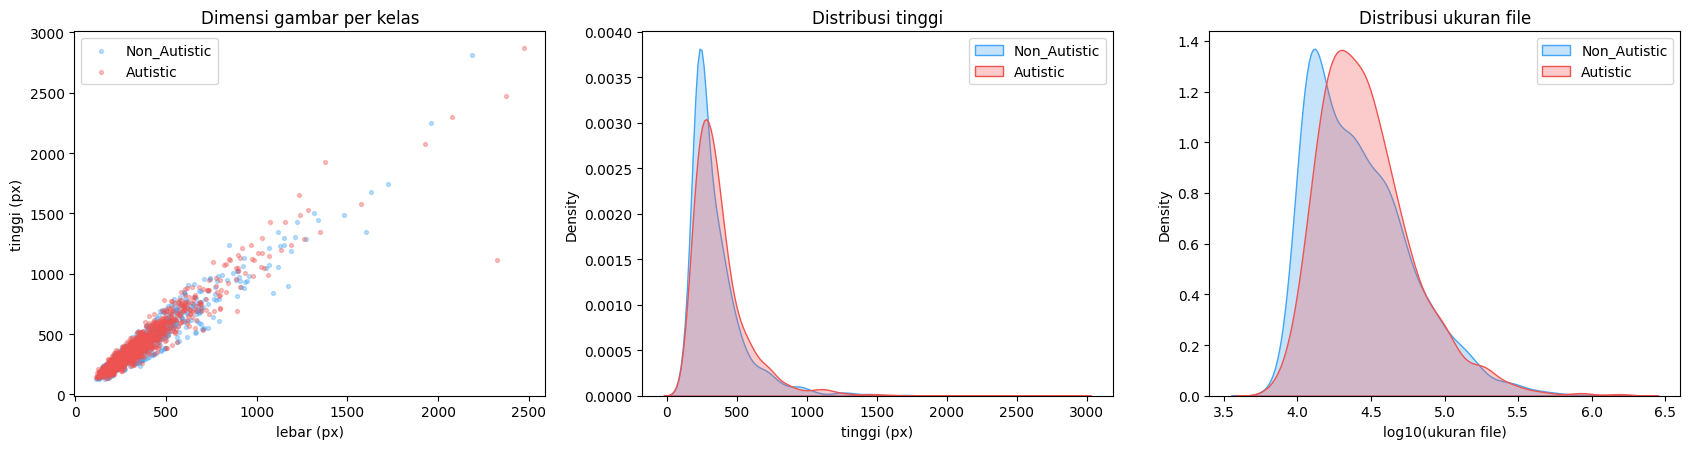

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for cls, col in zip(CLASSES, colors):
    s = props[props.class_name == cls]
    axes[0].scatter(s.width, s.height, s=8, alpha=.35, c=col, label=cls)
    sns.kdeplot(s.height, ax=axes[1], color=col, label=cls, fill=True, alpha=.3)
    sns.kdeplot(np.log10(s.bytes), ax=axes[2], color=col, label=cls, fill=True, alpha=.3)
axes[0].set_xlabel('lebar (px)'); axes[0].set_ylabel('tinggi (px)')
axes[0].set_title('Dimensi gambar per kelas'); axes[0].legend()
axes[1].set_xlabel('tinggi (px)'); axes[1].set_title('Distribusi tinggi'); axes[1].legend()
axes[2].set_xlabel('log10(ukuran file)'); axes[2].set_title('Distribusi ukuran file'); axes[2].legend()
plt.tight_layout(); plt.savefig('audit_shortcut.png', dpi=150); plt.show()

## 4b. Audit near-duplicate

Dataset tidak punya ID orang, jadi tidak ada cara membuktikan bahwa foto orang yang sama tidak
menyeberang split. dHash memberi batas bawah: gambar yang identik atau nyaris identik
setidaknya dapat dideteksi dan dikelompokkan.

Bila `GROUP_BY_NEAR_DUPLICATE = True`, group ini dipakai sebagai unit split. Itu tetap tidak
membuat split person-safe, hanya menghilangkan satu sumber kebocoran yang terukur.

In [9]:
def dhash(path, size=8):
    with Image.open(path) as im:
        gray = im.convert('L').resize((size + 1, size), Image.Resampling.LANCZOS)
        px = np.asarray(gray, dtype=np.int16)
    return np.packbits((px[:, 1:] > px[:, :-1]).astype(np.uint8)).tobytes().hex()

df['dhash'] = [dhash(p) for p in df.filepath]
df['group'] = pd.factorize(df['dhash'])[0]

dup = df.groupby('dhash').agg(n=('filepath','size'), n_label=('label','nunique'))
print(f'Total gambar                    : {len(df)}')
print(f'Group visual unik               : {df.group.nunique()}')
print(f'Group dengan >1 gambar          : {(dup.n > 1).sum()}')
print(f'Gambar dalam group duplikat     : {dup[dup.n > 1].n.sum()}')
print(f'Group dengan label bertentangan : {(dup.n_label > 1).sum()}')
print(f'\nCatatan: dHash hanya menangkap duplikat visual. Orang yang sama dengan pose,')
print(f'crop, atau pencahayaan berbeda TIDAK terdeteksi. Angka di atas adalah batas bawah.')

Total gambar                    : 2940
Group visual unik               : 2939
Group dengan >1 gambar          : 1
Gambar dalam group duplikat     : 2
Group dengan label bertentangan : 0

Catatan: dHash hanya menangkap duplikat visual. Orang yang sama dengan pose,
crop, atau pencahayaan berbeda TIDAK terdeteksi. Angka di atas adalah batas bawah.


## 5. Split

Split dilakukan langsung dari DataFrame, tanpa menyalin berkas ke direktori kerja lalu
melakukan glob ulang. Selain lebih cepat, ini menghilangkan satu titik di mana urutan
`CLASSES` dapat diam-diam mengubah pemetaan label.

In [10]:
if GROUP_BY_NEAR_DUPLICATE:
    outer = StratifiedGroupKFold(n_splits=int(round(1/TEST_RATIO)), shuffle=True, random_state=SEED)
    tv_idx, te_idx = next(outer.split(df, y=df.label, groups=df.group))
    df_tv, df_test = df.iloc[tv_idx].reset_index(drop=True), df.iloc[te_idx].reset_index(drop=True)
    inner = StratifiedGroupKFold(n_splits=int(round(1/(VAL_RATIO/(1-TEST_RATIO)))),
                                 shuffle=True, random_state=SEED + 1)
    tr_idx, va_idx = next(inner.split(df_tv, y=df_tv.label, groups=df_tv.group))
    df_train, df_val = df_tv.iloc[tr_idx].reset_index(drop=True), df_tv.iloc[va_idx].reset_index(drop=True)
    for a, b, na, nb in [(df_train, df_val, 'train', 'val'), (df_train, df_test, 'train', 'test'),
                         (df_val, df_test, 'val', 'test')]:
        ov = set(a.group) & set(b.group)
        assert not ov, f'Duplikat visual menyeberang {na}/{nb}: {len(ov)}'
    print('Split berbasis group near-duplicate. Tidak ada duplikat visual yang menyeberang.')
else:
    df_tv, df_test = train_test_split(df, test_size=TEST_RATIO, stratify=df.label, random_state=SEED)
    df_train, df_val = train_test_split(df_tv, test_size=VAL_RATIO/(1-TEST_RATIO),
                                        stratify=df_tv.label, random_state=SEED)
    print('Split acak per berkas — duplikat visual dapat menyeberang split.')

for name, d in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f'  {name:5s}: {len(d):5d} gambar | {d.class_name.value_counts().to_dict()}')

print('\nPERINGATAN: tidak ada participant ID. Split ini TIDAK dapat disebut person-safe.')

Split berbasis group near-duplicate. Tidak ada duplikat visual yang menyeberang.
  Train:  2101 gambar | {'Non_Autistic': 1052, 'Autistic': 1049}
  Val  :   420 gambar | {'Autistic': 211, 'Non_Autistic': 209}
  Test :   419 gambar | {'Autistic': 210, 'Non_Autistic': 209}

PERINGATAN: tidak ada participant ID. Split ini TIDAK dapat disebut person-safe.


## 6. Pipeline `tf.data`

`preprocess_input` EfficientNet menerima input dalam rentang `[0, 255]` dan menormalisasi
secara internal. Menggunakan `rescale=1./255` akan membuat model buta.

In [11]:
augmentation_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='augmentation')

def load_and_decode(filepath, label):
    raw = tf.io.read_file(filepath)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    return preprocess_input(img), label

def make_dataset(frame, training=False, cache=True, aug=None):
    ds = tf.data.Dataset.from_tensor_slices((frame.filepath.values,
                                             frame.label.values.astype('float32')))
    ds = ds.map(load_and_decode, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    if training:
        ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)
    layer = aug if aug is not None else (augmentation_layer if training else None)
    if layer is not None:
        ds = ds.map(lambda x, y: (layer(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val)
test_ds  = make_dataset(df_test)

y_val_true  = df_val.label.values.astype(float)
y_test_true = df_test.label.values.astype(float)
print(f'train {len(df_train)} | val {len(df_val)} | test {len(df_test)}')

I0000 00:00:1786109179.527457      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786109179.530750      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


train 2101 | val 420 | test 419


In [12]:
sample_batch, sample_labels = next(iter(train_ds))
print(f'Batch shape : {sample_batch.shape}')
print(f'Pixel min   : {sample_batch.numpy().min():.3f}')
print(f'Pixel max   : {sample_batch.numpy().max():.3f}')
print(f'Label sample: {sample_labels.numpy()[:8]}  (1 = {CLASSES[1]})')

2026-08-07 13:26:21.767647: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}


Batch shape : (32, 300, 300, 3)
Pixel min   : 0.000
Pixel max   : 255.000
Label sample: [0. 0. 1. 1. 0. 1. 1. 1.]  (1 = Autistic)


## 7. Arsitektur

`x = base(inp, training=...)` mengendalikan mode BatchNormalization, dan argumen ini
mengalahkan flag `trainable` pada masing-masing layer. Menyetel `training=True` saat
fine-tuning akan memaksa BatchNorm memakai statistik batch meskipun setiap layer BN sudah
`trainable=False`, sehingga statistik ImageNet rusak oleh batch kecil. Karena itu nilainya
dikunci `False`.

In [13]:
cw_arr = compute_class_weight('balanced', classes=np.unique(df_train.label.values),
                              y=df_train.label.values)
class_weight_dict = dict(enumerate(cw_arr))
print(f'Class weights: { {k: round(v,4) for k,v in class_weight_dict.items()} }')

def build_model():
    base = EfficientNetB3(include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
    base.trainable = False          # fase 1: hanya head yang dilatih

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x = base(inp, training=False)          # BatchNorm selalu dalam mode inferensi
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='gelu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='gelu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out), base

model, base_model = build_model()
print(f'Total params     : {model.count_params():,}')
print(f'Trainable params : {sum(np.prod(v.shape) for v in model.trainable_weights):,}')

Class weights: {0: np.float64(0.9986), 1: np.float64(1.0014)}
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 11,708,208
Trainable params : 921,601


## 8. Learning rate: warmup dan cosine decay

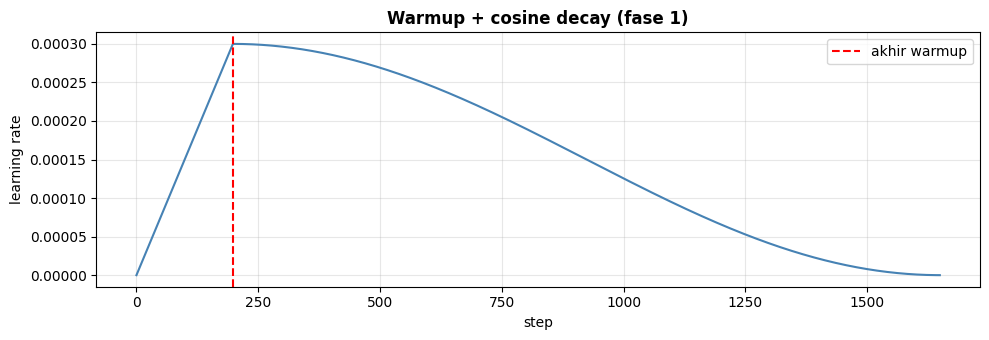

In [14]:
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, total_steps, warmup_steps):
        super().__init__()
        self.peak_lr, self.total_steps, self.warmup_steps = peak_lr, total_steps, warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.peak_lr * (step / self.warmup_steps)
        cosine_lr = self.peak_lr * 0.5 * (
            1 + tf.cos(np.pi * (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)))
        return tf.cond(step < self.warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        return {'peak_lr': self.peak_lr, 'total_steps': self.total_steps,
                'warmup_steps': self.warmup_steps}

steps_per_epoch = len(train_ds)
total_steps_p1, warmup_steps_p1 = EPOCHS_P1 * steps_per_epoch, WARMUP_P1 * steps_per_epoch

sched = WarmupCosineDecay(LR_P1, total_steps_p1, warmup_steps_p1)
plt.figure(figsize=(10, 3.5))
plt.plot([sched(i).numpy() for i in range(total_steps_p1)], color='steelblue')
plt.axvline(warmup_steps_p1, color='red', ls='--', label='akhir warmup')
plt.title('Warmup + cosine decay (fase 1)', fontweight='bold')
plt.xlabel('step'); plt.ylabel('learning rate'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 9. Fase 1, feature extraction

In [15]:
METRICS = lambda: [keras.metrics.BinaryAccuracy(name='accuracy'),
                   keras.metrics.AUC(name='auc'),
                   keras.metrics.Precision(name='precision'),
                   keras.metrics.Recall(name='recall')]

model.compile(optimizer=keras.optimizers.AdamW(WarmupCosineDecay(LR_P1, total_steps_p1, warmup_steps_p1),
                                               weight_decay=1e-5),
              loss=keras.losses.BinaryCrossentropy(label_smoothing=0.1),
              metrics=METRICS())

callbacks_p1 = [
    EarlyStopping(monitor='val_auc', patience=8, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('/kaggle/working/best_p1.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)]

print(f'Fase 1: max {EPOCHS_P1} epoch | LR peak {LR_P1} | warmup {WARMUP_P1} epoch')
history_p1 = model.fit(train_ds, epochs=EPOCHS_P1, validation_data=val_ds,
                       callbacks=callbacks_p1, class_weight=class_weight_dict, verbose=1)

Fase 1: max 25 epoch | LR peak 0.0003 | warmup 3 epoch
Epoch 1/25


2026-08-07 13:26:36.402648: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}
E0000 00:00:1786109214.499427      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptim

66/66 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5640 - auc: 0.5935 - loss: 0.8969 - precision: 0.5530 - recall: 0.6616 - val_accuracy: 0.7310 - val_auc: 0.7868 - val_loss: 0.7399 - val_precision: 0.7402 - val_recall: 0.7156
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.6802 - auc: 0.7429 - loss: 0.7624 - precision: 0.6780 - recall: 0.6845 - val_accuracy: 0.7357 - val_auc: 0.8265 - val_loss: 0.6954 - val_precision: 0.7874 - val_recall: 0.6493
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.6892 - auc: 0.7582 - loss: 0.7545 - precision: 0.6861 - recall: 0.6959 - val_accuracy: 0.7476 - val_auc: 0.8408 - val_loss: 0.6651 - val_precision: 0.7720 - val_recall: 0.7062
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7092 - auc: 0.7825 - loss: 0.7283 - precision: 0.7066 - recall: 0.7140 - val_accuracy: 0.7667 - val_auc: 0.8499 - val_loss: 0.6477 - val_precision: 0.8054 - val_recall: 0.7062
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step 

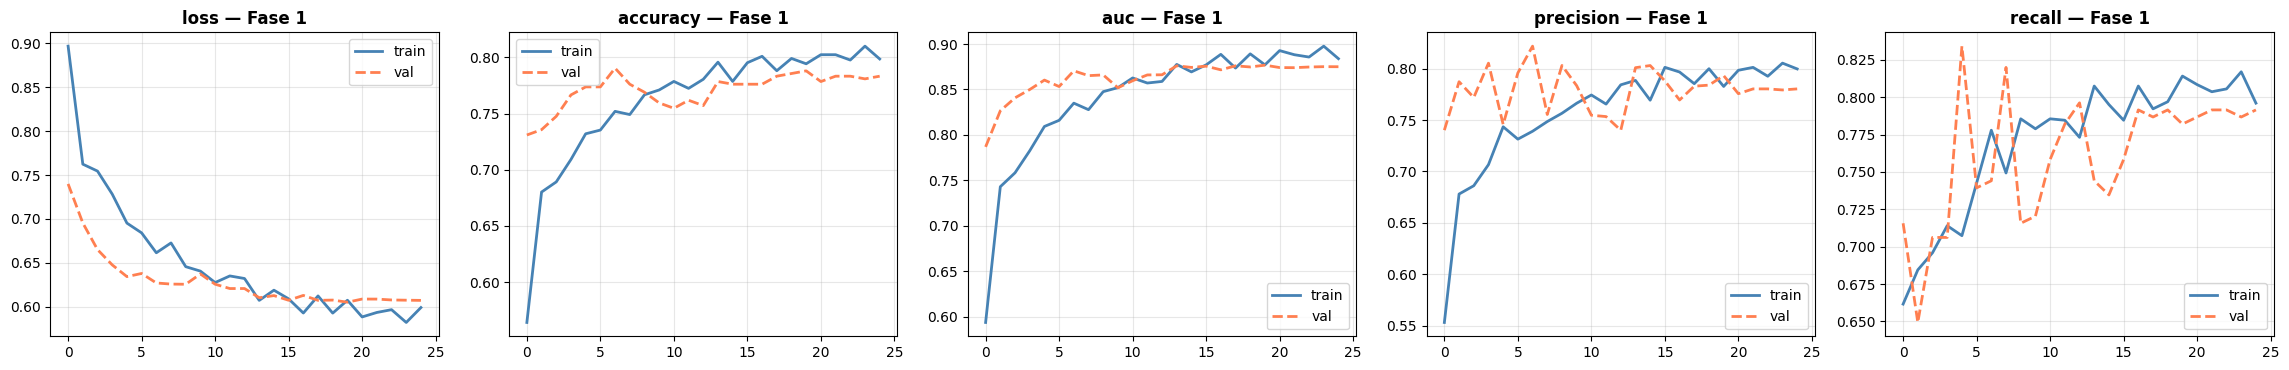

In [16]:
def plot_history(hist, title=''):
    metrics = [m for m in ['loss','accuracy','auc','precision','recall'] if m in hist.history]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.6*len(metrics), 3.8))
    if len(metrics) == 1: axes = [axes]
    for ax, m in zip(axes, metrics):
        ax.plot(hist.history[m], label='train', color='steelblue', lw=2)
        ax.plot(hist.history[f'val_{m}'], label='val', color='coral', lw=2, ls='--')
        ax.set_title(f'{m} — {title}', fontweight='bold'); ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'curve_{title.replace(" ","_").lower()}.png', dpi=120); plt.show()

plot_history(history_p1, 'Fase 1')

## 10. Fase 2, fine-tuning

Trainable base layers: 39/385
Fase 2: max 30 epoch | LR peak 5e-05 | unfreeze 50 layer
Epoch 26/55


2026-08-07 14:02:38.073813: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}
E0000 00:00:1786111380.428353      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptim

66/66 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7939 - auc: 0.8854 - loss: 0.5657 - precision: 0.7962 - recall: 0.7893 - val_accuracy: 0.7929 - val_auc: 0.8812 - val_loss: 0.5721 - val_precision: 0.7925 - val_recall: 0.7962
Epoch 27/55
66/66 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8068 - auc: 0.8935 - loss: 0.5559 - precision: 0.8030 - recall: 0.8122 - val_accuracy: 0.7786 - val_auc: 0.8825 - val_loss: 0.5729 - val_precision: 0.7682 - val_recall: 0.8009
Epoch 28/55
66/66 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8087 - auc: 0.8947 - loss: 0.5524 - precision: 0.8032 - recall: 0.8170 - val_accuracy: 0.7952 - val_auc: 0.8914 - val_loss: 0.5579 - val_precision: 0.8049 - val_recall: 0.7820
Epoch 29/55
66/66 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8220 - auc: 0.9037 - loss: 0.5383 - precision: 0.8054 - recall: 0.8484 - val_accuracy: 0.8024 - val_auc: 0.8888 - val_loss: 0.5611 - val_precision: 0.7991 - val_recall: 0.8104
Epoch 30/55
66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/s

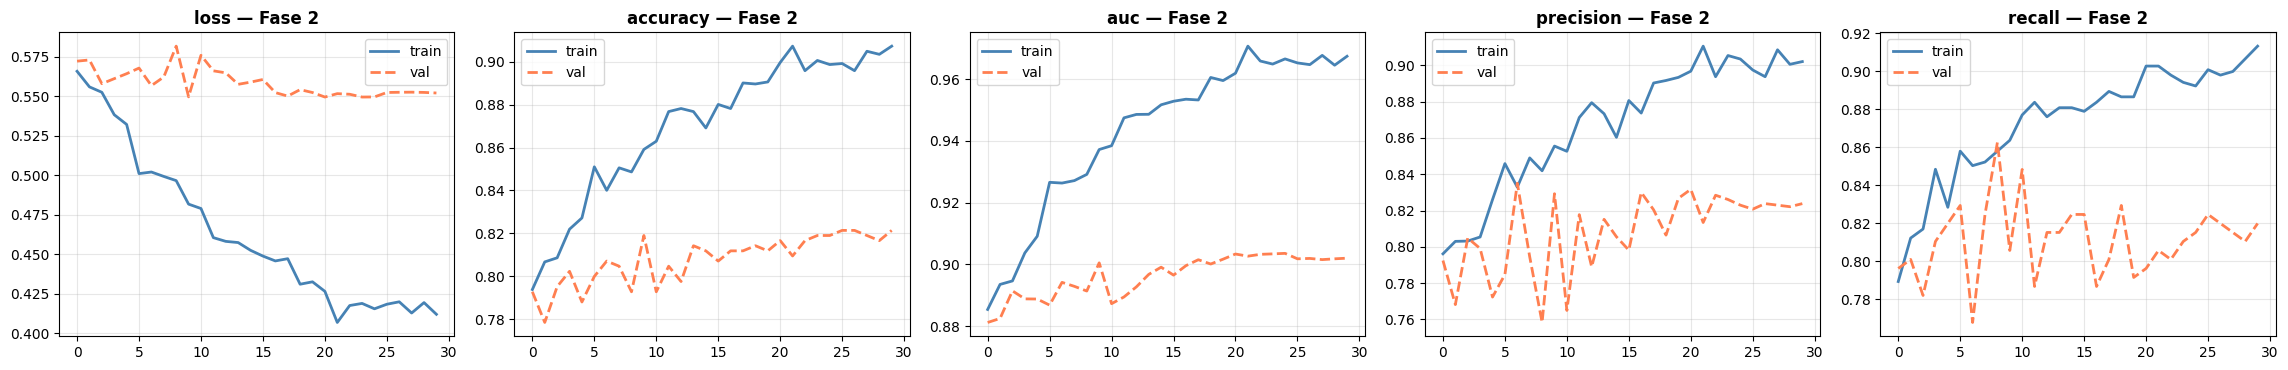

In [17]:
# Muat model utuh, lalu ubah flag trainable pada objek yang sama. Membangun ulang
# arsitektur lalu load_weights berisiko gagal karena penamaan layer otomatis berubah
# pada instansiasi kedua di sesi yang sama.
model = keras.models.load_model('/kaggle/working/best_p1.keras', compile=False)
base_model = next(l for l in model.layers if isinstance(l, keras.Model))

base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_N]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f'Trainable base layers: {sum(1 for l in base_model.layers if l.trainable)}/{len(base_model.layers)}')

initial_epoch = len(history_p1.history['loss'])
total_steps_p2, warmup_steps_p2 = EPOCHS_P2 * steps_per_epoch, WARMUP_P2 * steps_per_epoch

model.compile(optimizer=keras.optimizers.AdamW(WarmupCosineDecay(LR_P2, total_steps_p2, warmup_steps_p2),
                                               weight_decay=1e-5),
              loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
              metrics=METRICS())

callbacks_p2 = [
    EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True, mode='max', verbose=1),
    ModelCheckpoint('/kaggle/working/best_final.keras', monitor='val_auc',
                    save_best_only=True, mode='max', verbose=0)]

print(f'Fase 2: max {EPOCHS_P2} epoch | LR peak {LR_P2} | unfreeze {UNFREEZE_N} layer')
history_p2 = model.fit(train_ds, epochs=initial_epoch + EPOCHS_P2, initial_epoch=initial_epoch,
                       validation_data=val_ds, callbacks=callbacks_p2,
                       class_weight=class_weight_dict, verbose=1)
plot_history(history_p2, 'Fase 2')

## 11. Evaluasi

Threshold adalah hyperparameter. Menghitung Youden J pada prediksi test lalu melaporkan
sensitivity dan specificity pada test yang sama berarti memilih hyperparameter di data uji,
dan angka yang dihasilkan optimistis.

Urutan yang dipakai di sini: mode inferensi dan Youden J ditentukan pada validation, threshold
dikunci, baru test disentuh satu kali.

In [18]:
best = keras.models.load_model('/kaggle/working/best_final.keras', compile=False)
best.compile(optimizer=keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=METRICS())

TTA_STEPS = 10
tta_aug = keras.Sequential([layers.RandomFlip('horizontal'),
                            layers.RandomRotation(0.05),
                            layers.RandomZoom(0.05)], name='tta')

def predict_tta(frame, steps=TTA_STEPS):
    preds = [best.predict(make_dataset(frame), verbose=0).ravel()]
    for _ in range(steps):
        preds.append(best.predict(make_dataset(frame, aug=tta_aug), verbose=0).ravel())
    return np.mean(preds, axis=0)

# Validation: pilih mode inferensi dan threshold, lalu kunci
val_raw = best.predict(val_ds, verbose=0).ravel()
val_tta = predict_tta(df_val)
auc_val = {'plain': roc_auc_score(y_val_true, val_raw), 'tta': roc_auc_score(y_val_true, val_tta)}
MODE = max(auc_val, key=auc_val.get)
val_prob = val_raw if MODE == 'plain' else val_tta

fpr_v, tpr_v, thr_v = roc_curve(y_val_true, val_prob)
LOCKED_THRESHOLD = float(thr_v[int(np.argmax(tpr_v - fpr_v))])

print('=== Dikunci dari VALIDATION ===')
print(f'  AUC val plain : {auc_val["plain"]:.4f}')
print(f'  AUC val TTA   : {auc_val["tta"]:.4f}')
print(f'  Mode dipilih  : {MODE}')
print(f'  Threshold     : {LOCKED_THRESHOLD:.4f}  (Youden J pada validation)')
print(f'  Sensitivitas {POS_NAME} pada val : {tpr_v[int(np.argmax(tpr_v - fpr_v))]:.4f}')
print(f'  Spesifisitas pada val            : {1 - fpr_v[int(np.argmax(tpr_v - fpr_v))]:.4f}')

2026-08-07 14:47:17.492375: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}
2026-08-07 14:47:31.235279: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),m

=== Dikunci dari VALIDATION ===
  AUC val plain : 0.9038
  AUC val TTA   : 0.9121
  Mode dipilih  : tta
  Threshold     : 0.5436  (Youden J pada validation)
  Sensitivitas Autistic pada val : 0.7915
  Spesifisitas pada val            : 0.8947


In [19]:
# Test: satu kali, dengan threshold yang sudah dikunci
test_raw = best.predict(test_ds, verbose=0).ravel()
test_prob = test_raw if MODE == 'plain' else predict_tta(df_test)
y_pred = (test_prob >= LOCKED_THRESHOLD).astype(int)

roc_auc_test = roc_auc_score(y_test_true, test_prob)
tn, fp, fn, tp = confusion_matrix(y_test_true, y_pred).ravel()

def bootstrap_auc(y, p, n=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed); y, p = np.asarray(y), np.asarray(p); out = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        if len(np.unique(y[i])) > 1:
            out.append(roc_auc_score(y[i], p[i]))
    out = np.array(out)
    return out.mean(), np.percentile(out, 2.5), np.percentile(out, 97.5), out

_, lo, hi, dist = bootstrap_auc(y_test_true, test_prob)

print(f'=== TEST SET — threshold dikunci dari validation ({LOCKED_THRESHOLD:.4f}) ===')
print(f'n test                    : {len(y_test_true)} '
      f'({int(y_test_true.sum())} {CLASSES[1]} / {int((1-y_test_true).sum())} {CLASSES[0]})')
print(f'ROC-AUC                   : {roc_auc_test:.4f}  (95% CI {lo:.4f}-{hi:.4f})')
print(f'Average precision         : {average_precision_score(y_test_true, test_prob):.4f}')
print(f'Accuracy                  : {accuracy_score(y_test_true, y_pred):.4f}')
print(f'Balanced accuracy         : {balanced_accuracy_score(y_test_true, y_pred):.4f}')
print(f'MCC                       : {matthews_corrcoef(y_test_true, y_pred):.4f}')
print(f'Sensitivitas {POS_NAME:12}: {tp/(tp+fn):.4f}   ({tp}/{tp+fn})   <-- benar-benar ASD')
print(f'Spesifisitas              : {tn/(tn+fp):.4f}   ({tn}/{tn+fp})')
print()
print(classification_report(y_test_true, y_pred, target_names=CLASSES, digits=4))

2026-08-07 14:49:40.464037: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}
2026-08-07 14:49:54.146525: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),m

=== TEST SET — threshold dikunci dari validation (0.5436) ===
n test                    : 419 (210 Autistic / 209 Non_Autistic)
ROC-AUC                   : 0.9324  (95% CI 0.9070-0.9537)
Average precision         : 0.9266
Accuracy                  : 0.8425
Balanced accuracy         : 0.8425
MCC                       : 0.6861
Sensitivitas Autistic    : 0.8143   (171/210)   <-- benar-benar ASD
Spesifisitas              : 0.8708   (182/209)

              precision    recall  f1-score   support

Non_Autistic     0.8235    0.8708    0.8465       209
    Autistic     0.8636    0.8143    0.8382       210

    accuracy                         0.8425       419
   macro avg     0.8436    0.8425    0.8424       419
weighted avg     0.8436    0.8425    0.8424       419



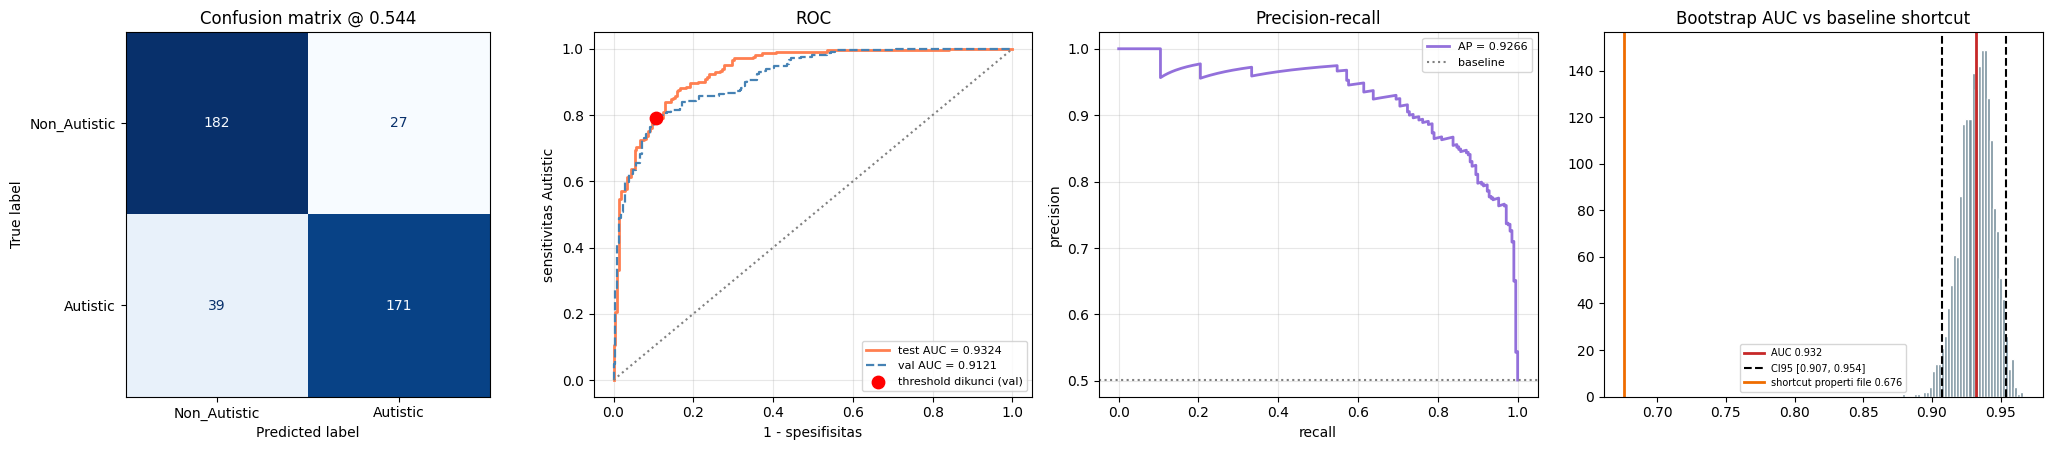

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6))

cm = confusion_matrix(y_test_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion matrix @ {LOCKED_THRESHOLD:.3f}')

fpr_t, tpr_t, _ = roc_curve(y_test_true, test_prob)
axes[1].plot(fpr_t, tpr_t, color='coral', lw=2, label=f'test AUC = {roc_auc_test:.4f}')
axes[1].plot(fpr_v, tpr_v, color='steelblue', lw=1.6, ls='--', label=f'val AUC = {auc_val[MODE]:.4f}')
j = int(np.argmax(tpr_v - fpr_v))
axes[1].scatter(fpr_v[j], tpr_v[j], color='red', s=80, zorder=5, label='threshold dikunci (val)')
axes[1].plot([0,1],[0,1], ls=':', color='gray')
axes[1].set_xlabel('1 - spesifisitas'); axes[1].set_ylabel(f'sensitivitas {POS_NAME}')
axes[1].set_title('ROC'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)

prec, rec, _ = precision_recall_curve(y_test_true, test_prob)
axes[2].plot(rec, prec, color='mediumpurple', lw=2,
             label=f'AP = {average_precision_score(y_test_true, test_prob):.4f}')
axes[2].axhline(y_test_true.mean(), ls=':', color='gray', label='baseline')
axes[2].set_xlabel('recall'); axes[2].set_ylabel('precision')
axes[2].set_title('Precision-recall'); axes[2].legend(fontsize=8); axes[2].grid(alpha=.3)

axes[3].hist(dist, bins=40, color='#78909C', edgecolor='white')
axes[3].axvline(roc_auc_test, color='#C62828', lw=2, label=f'AUC {roc_auc_test:.3f}')
axes[3].axvline(lo, color='black', ls='--'); axes[3].axvline(hi, color='black', ls='--',
                                                             label=f'CI95 [{lo:.3f}, {hi:.3f}]')
axes[3].axvline(max(auc_lr, auc_gb), color='#EF6C00', lw=2,
                label=f'shortcut properti file {max(auc_lr, auc_gb):.3f}')
axes[3].set_title('Bootstrap AUC vs baseline shortcut'); axes[3].legend(fontsize=7)

plt.tight_layout(); plt.savefig('hasil_test.png', dpi=150); plt.show()

## 12. Analisis kesalahan

In [21]:
wrong = np.where(y_pred != y_test_true)[0]
print(f'Salah klasifikasi: {len(wrong)}/{len(y_test_true)} ({len(wrong)/len(y_test_true)*100:.1f}%)')

n_show = min(12, len(wrong))
if n_show:
    fig, axes = plt.subplots(2, 6, figsize=(20, 8))
    fig.suptitle(f'Sampel salah klasifikasi (n={n_show})', fontsize=13, fontweight='bold')
    fps = df_test.filepath.values
    for ax, idx in zip(axes.flat, wrong[:n_show]):
        ax.imshow(mpimg.imread(fps[idx]))
        ax.set_title(f'benar: {CLASSES[int(y_test_true[idx])]}\n'
                     f'prediksi: {CLASSES[int(y_pred[idx])]}\n'
                     f'p({POS_NAME})={test_prob[idx]:.2f}', fontsize=8, color='red')
        ax.axis('off')
    for ax in axes.flat[n_show:]: ax.axis('off')
    plt.tight_layout(); plt.savefig('misclassified.png', dpi=120); plt.show()

Salah klasifikasi: 66/419 (15.8%)


[keluaran gambar dihapus sebelum publikasi: sel ini merender wajah anak beserta labelnya. Angka dan grafik lain di notebook ini utuh. Lihat docs/pembersihan_dataset_wajah.md]


## 13. Ekspor artefak

Model dari dataset terkarantina tidak boleh diekspor. Sel di bawah tidak berjalan selama
`ALLOW_MODEL_EXPORT = False`.

In [22]:
if ALLOW_MODEL_EXPORT and not missing:
    best.save('/kaggle/working/autism_effb3_final.keras')
    conv = tf.lite.TFLiteConverter.from_keras_model(best)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    open('/kaggle/working/autism_effb3.tflite', 'wb').write(conv.convert())
    print('Artefak diekspor.')
else:
    print('Ekspor DIBLOKIR.')
    print(f'  ALLOW_MODEL_EXPORT = {ALLOW_MODEL_EXPORT}')
    print(f'  metadata governance belum lengkap: {missing}')
    print('\nModel wajah tidak diimpor ke Neurogaze dalam kondisi apa pun saat ini.')

Ekspor DIBLOKIR.
  ALLOW_MODEL_EXPORT = False
  metadata governance belum lengkap: ['provenance_sumber_gambar', 'lisensi_eksplisit', 'consent_subjek', 'metadata_demografi', 'definisi_label_klinis', 'participant_id']

Model wajah tidak diimpor ke Neurogaze dalam kondisi apa pun saat ini.


## 14. Kesimpulan audit

### Pipeline

Kelas positif `Autistic` = label 1, diverifikasi assertion. Split group near-duplicate (dHash)
70/15/15, bukan person-safe. Preprocessing lewat `efficientnet.preprocess_input()` dengan input
`[0, 255]`. Base model EfficientNetB3 ImageNet, BatchNorm selalu mode inferensi. Fine-tuning
membuka 50 layer terakhir. Mode inferensi dan threshold dipilih pada validation. Ketidakpastian
dari bootstrap 2.000 resample pada test.

### Yang boleh dikutip di paper

Shortcut koleksi terkonfirmasi. Classifier tanpa piksel, hanya dimensi, ukuran berkas, dan
turunannya, sudah mencapai AUC yang dicetak di sel audit. Ini bukti bahwa label berkorelasi
dengan proses pengumpulan gambar.

Threshold dikunci dari validation. Sensitivity dan specificity yang dilaporkan berasal dari
ambang yang tidak pernah melihat data uji, dan kelas positifnya benar-benar ASD. Keduanya
syarat minimum agar angka dapat dibandingkan dengan studi lain.

Governance sebagai kriteria kelayakan. Enam metadata wajib absen, sehingga dataset ditolak
untuk pemodelan ASD terlepas dari seberapa tinggi metriknya.

### Yang tidak boleh dikutip

- Angka mana pun di notebook ini sebagai performa deteksi ASD.
- Klaim "no data leakage". Tanpa participant ID, klaim itu tidak dapat dibuktikan.
- Perbandingan langsung dengan model eye-tracking. Tugas, populasi, dan modalitasnya berbeda.

### Syarat agar karantina dapat dicabut

Keenam item pada `GOVERNANCE` harus terpenuhi: provenance sumber gambar, lisensi eksplisit,
consent subjek, metadata demografi, definisi label klinis yang operasional, dan participant ID.
Bila kelak tersedia, pipeline ini sudah siap dijalankan dengan kelas positif yang benar dan
threshold dari validation.

In [23]:
print('='*70)
print('RINGKASAN UNTUK PAPER — dataset wajah (TERKARANTINA)')
print('='*70)
print(f'Dataset             : {len(df)} gambar, {df.group.nunique()} group visual unik')
print(f'Participant ID      : TIDAK ADA')
print(f'Status governance   : {len(missing)}/6 metadata wajib tidak tersedia')
print()
print(f'AUC shortcut (tanpa piksel, properti berkas saja):')
print(f'  logistic regression : {auc_lr:.4f}')
print(f'  gradient boosting   : {auc_gb:.4f}')
print()
print(f'AUC CNN EfficientNetB3 (threshold dari validation):')
print(f'  test AUC            : {roc_auc_test:.4f}  (95% CI {lo:.4f}-{hi:.4f})')
print(f'  threshold dikunci   : {LOCKED_THRESHOLD:.4f}  (mode {MODE})')
print(f'  sensitivitas ASD    : {tp/(tp+fn):.4f}')
print(f'  spesifisitas        : {tn/(tn+fp):.4f}')
print(f'  balanced accuracy   : {balanced_accuracy_score(y_test_true, y_pred):.4f}')
print()
print('KEPUTUSAN: dataset tetap reject_for_asd_modeling_and_quarantine.')
print('='*70)

json.dump({'status': 'quarantined',
           'governance_missing': missing,
           'auc_shortcut_logreg': float(auc_lr),
           'auc_shortcut_gbm': float(auc_gb),
           'auc_cnn_test': float(roc_auc_test),
           'ci95': [float(lo), float(hi)],
           'threshold_dari_validation': LOCKED_THRESHOLD,
           'mode_inferensi': MODE,
           'sensitivitas_asd': float(tp/(tp+fn)),
           'spesifisitas': float(tn/(tn+fp)),
           'n_test': int(len(y_test_true))},
          open('/kaggle/working/hasil_audit_wajah.json','w'), indent=2)

RINGKASAN UNTUK PAPER — dataset wajah (TERKARANTINA)
Dataset             : 2940 gambar, 2939 group visual unik
Participant ID      : TIDAK ADA
Status governance   : 6/6 metadata wajib tidak tersedia

AUC shortcut (tanpa piksel, properti berkas saja):
  logistic regression : 0.4778
  gradient boosting   : 0.6757

AUC CNN EfficientNetB3 (threshold dari validation):
  test AUC            : 0.9324  (95% CI 0.9070-0.9537)
  threshold dikunci   : 0.5436  (mode tta)
  sensitivitas ASD    : 0.8143
  spesifisitas        : 0.8708
  balanced accuracy   : 0.8425

KEPUTUSAN: dataset tetap reject_for_asd_modeling_and_quarantine.
